# 🏥 Hospital Readmission Rate Analysis — CMS FY2026
## Notebook 3: Publication-Quality Visualizations
**Author:** Loknadh V K S Kona | [GitHub](https://github.com/KrishnaSai315) | [LinkedIn](https://linkedin.com/in/lvkrishna3)  
**Output:** Charts saved to `assets/` folder → used in GitHub README + LinkedIn post

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Output folder
os.makedirs('assets', exist_ok=True)

# ── Healthcare color palette (clinical, professional)
C = {
    'primary'  : '#1a5276',   # Deep clinical blue
    'danger'   : '#c0392b',   # Red  — high risk / penalized
    'safe'     : '#1e8449',   # Green — below average / top performer
    'neutral'  : '#7f8c8d',   # Gray
    'highlight': '#f39c12',   # Amber — benchmark lines
    'light'    : '#d6eaf8',   # Light blue — background accents
    'purple'   : '#6c3483',   # Purple — secondary accent
}

# ── Global style
plt.rcParams.update({
    'font.family'    : 'sans-serif',
    'font.size'      : 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi'     : 100,
})

# ── Load data
df           = pd.read_csv('data/processed/readmission_clean.csv')
df_condition = pd.read_csv('data/processed/condition_summary.csv')
df_state     = pd.read_csv('data/processed/state_summary.csv')
df_type      = pd.read_csv('data/processed/hospital_type_summary.csv')
df_cost      = pd.read_csv('data/processed/cost_by_condition.csv')

NATIONAL_AVG_ERR = df['excess_readmit_ratio'].mean()
print(f'Data loaded. National avg ERR: {NATIONAL_AVG_ERR:.4f}')

Data loaded. National avg ERR: 1.0020


---
## Chart 1: ERR Distribution by Condition (Box Plot)
*Shows spread of hospital performance within each clinical condition*

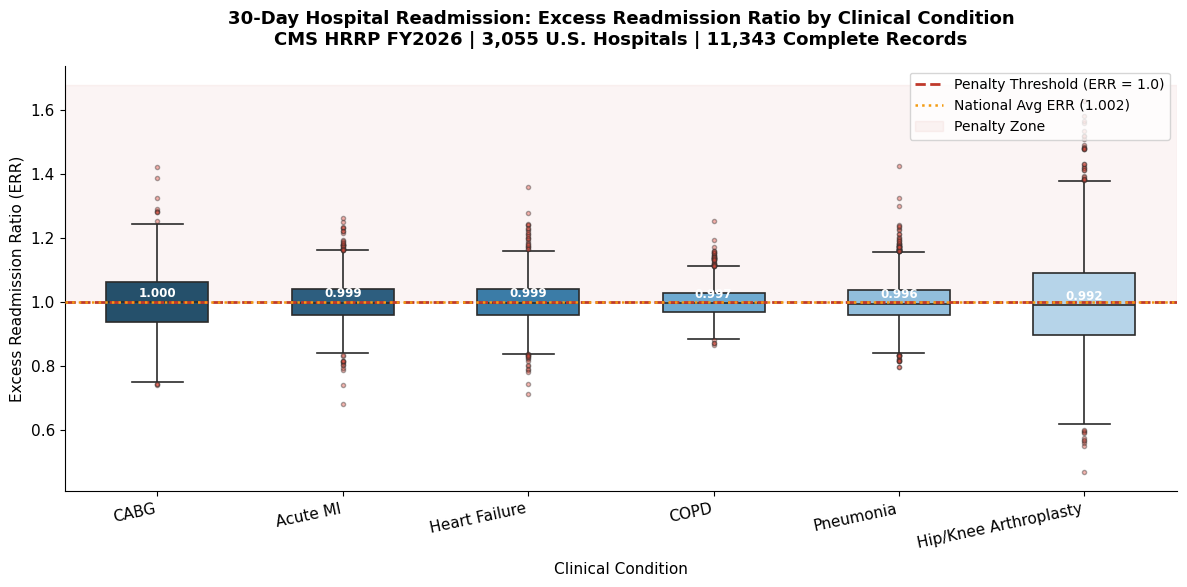

Saved: assets/chart1_err_by_condition.png


In [5]:
# Order conditions by median ERR (descending)
condition_order = (
    df.groupby('condition')['excess_readmit_ratio']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df, x='condition', y='excess_readmit_ratio',
    order=condition_order,
    palette=['#1a5276','#1f618d','#2980b9','#5dade2','#85c1e9','#aed6f1'],
    width=0.55, linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor='#e74c3c',
                    markersize=3, alpha=0.4),
    ax=ax
)

# Penalty threshold line
ax.axhline(y=1.0, color=C['danger'], linestyle='--',
           linewidth=2, label='Penalty Threshold (ERR = 1.0)', zorder=5)

# National average line
ax.axhline(y=NATIONAL_AVG_ERR, color=C['highlight'], linestyle=':',
           linewidth=1.8, label=f'National Avg ERR ({NATIONAL_AVG_ERR:.3f})', zorder=5)

# Shade the penalty zone
ax.axhspan(1.0, df['excess_readmit_ratio'].max() + 0.05,
           alpha=0.05, color=C['danger'], label='Penalty Zone')

ax.set_title(
    '30-Day Hospital Readmission: Excess Readmission Ratio by Clinical Condition\n'
    'CMS HRRP FY2026 | 3,055 U.S. Hospitals | 11,343 Complete Records',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Clinical Condition', fontsize=11, labelpad=8)
ax.set_ylabel('Excess Readmission Ratio (ERR)', fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.set_xticklabels(condition_order, rotation=12, ha='right')

# Annotate median ERR on each box
for i, cond in enumerate(condition_order):
    med = df[df['condition'] == cond]['excess_readmit_ratio'].median()
    ax.text(i, med + 0.008, f'{med:.3f}', ha='center', va='bottom',
            fontsize=8.5, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('assets/chart1_err_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: assets/chart1_err_by_condition.png')

---
## Chart 2: State Performance — Horizontal Bar Chart
*All 51 states benchmarked against national average ERR*

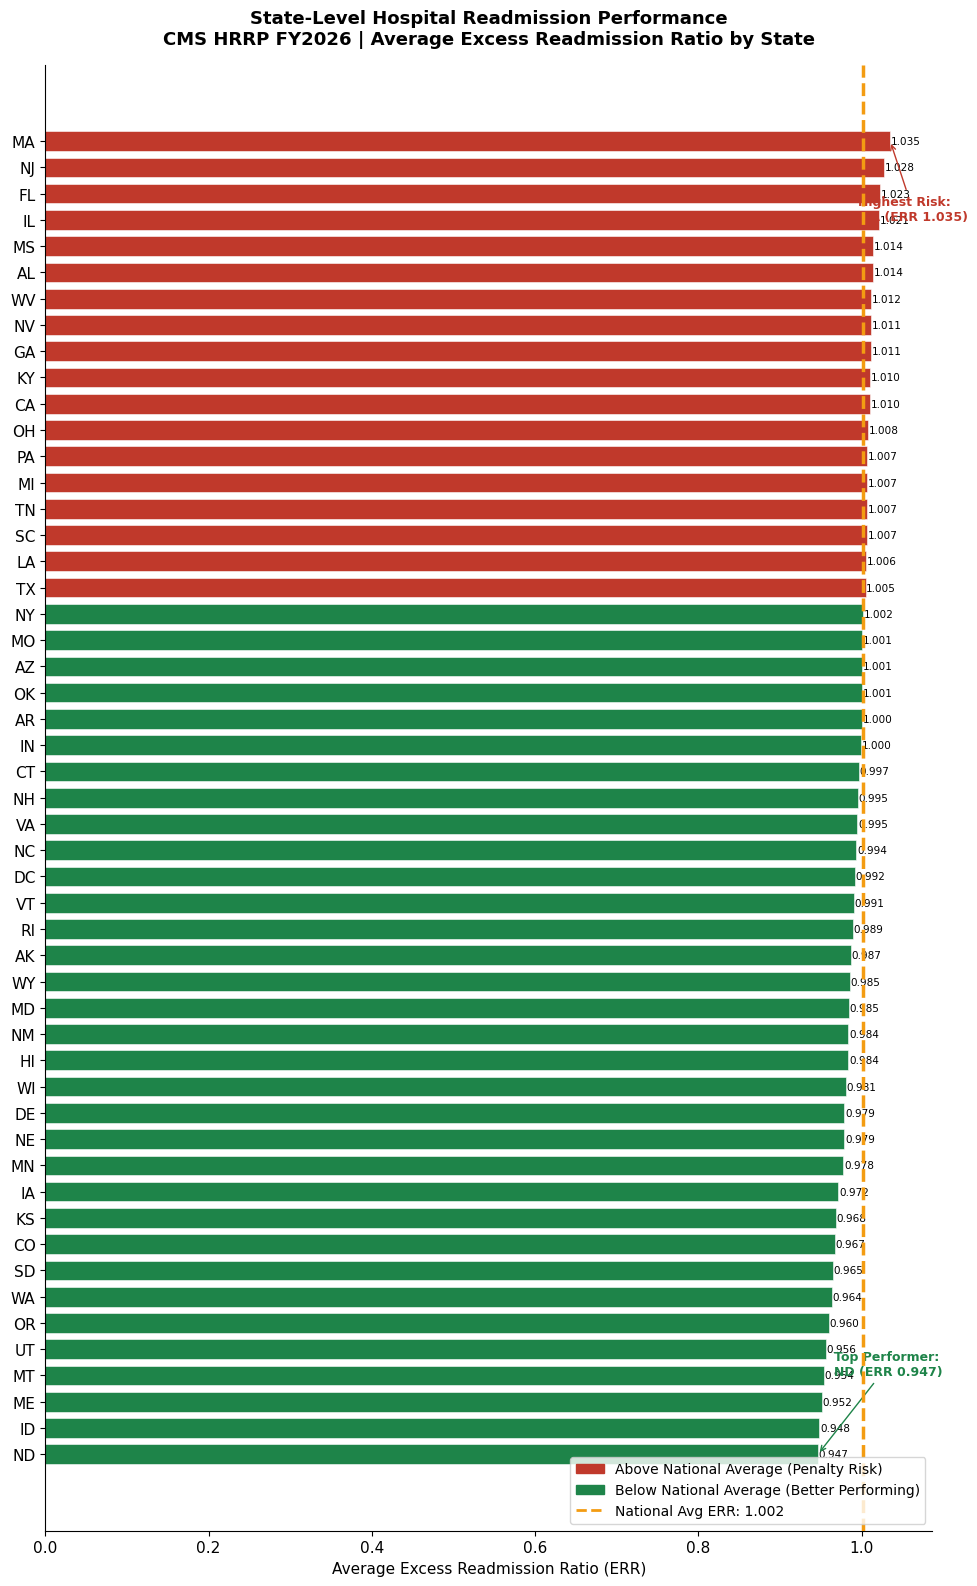

Saved: assets/chart2_state_performance.png


In [8]:
df_state_sorted = df_state.sort_values('state_avg_err', ascending=True)

# Color: red = above avg, green = below avg
colors = [
    C['danger'] if e > NATIONAL_AVG_ERR else C['safe']
    for e in df_state_sorted['state_avg_err']
]

fig, ax = plt.subplots(figsize=(10, 16))

bars = ax.barh(
    df_state_sorted['state'],
    df_state_sorted['state_avg_err'],
    color=colors, edgecolor='white', linewidth=0.4, height=0.75
)

# National average reference line
ax.axvline(x=NATIONAL_AVG_ERR, color=C['highlight'],
           linewidth=2.5, linestyle='--',
           label=f'National Avg ERR: {NATIONAL_AVG_ERR:.3f}', zorder=5)

# Labels on each bar
for bar, val in zip(bars, df_state_sorted['state_avg_err']):
    ax.text(
        val + 0.001, bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center', ha='left', fontsize=7.5
    )

# Legend patches
above_patch = mpatches.Patch(color=C['danger'],
                              label='Above National Average (Penalty Risk)')
below_patch = mpatches.Patch(color=C['safe'],
                              label='Below National Average (Better Performing)')
ax.legend(handles=[above_patch, below_patch,
                   plt.Line2D([0],[0], color=C['highlight'],
                              linewidth=2, linestyle='--',
                              label=f'National Avg ERR: {NATIONAL_AVG_ERR:.3f}')],
          fontsize=10, loc='lower right')

ax.set_title(
    'State-Level Hospital Readmission Performance\n'
    'CMS HRRP FY2026 | Average Excess Readmission Ratio by State',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Average Excess Readmission Ratio (ERR)', fontsize=11)
ax.set_ylabel('')

# Annotate top/bottom states
top_state    = df_state_sorted.iloc[-1]
bottom_state = df_state_sorted.iloc[0]
ax.annotate(f'Highest Risk:\n{top_state["state"]} (ERR {top_state["state_avg_err"]:.3f})',
            xy=(top_state['state_avg_err'], len(df_state_sorted)-1),
            xytext=(top_state['state_avg_err'] - 0.04, len(df_state_sorted)-4),
            fontsize=9, color=C['danger'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C['danger']))

ax.annotate(f'Top Performer:\n{bottom_state["state"]} (ERR {bottom_state["state_avg_err"]:.3f})',
            xy=(bottom_state['state_avg_err'], 0),
            xytext=(bottom_state['state_avg_err'] + 0.02, 3),
            fontsize=9, color=C['safe'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C['safe']))

plt.tight_layout()
plt.savefig('assets/chart2_state_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: assets/chart2_state_performance.png')

---
## Chart 3: Readmission Volume vs Excess Cost by Condition
*Bubble chart — size = total readmissions, position = cost vs rate*

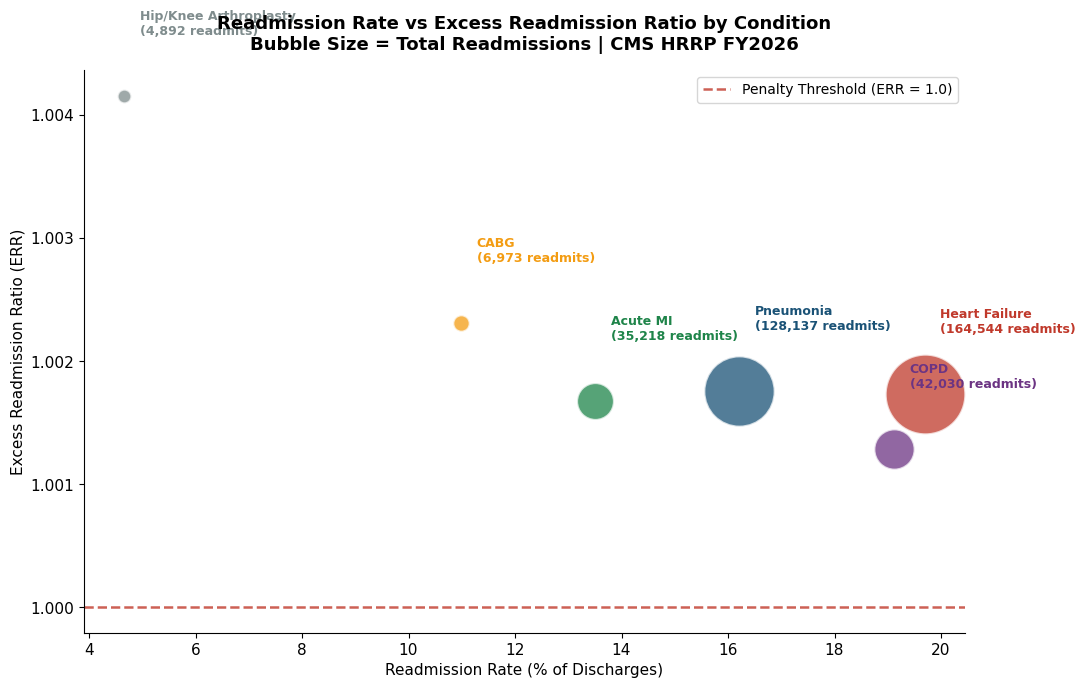

Saved: assets/chart3_condition_bubble.png


In [11]:
fig, ax = plt.subplots(figsize=(11, 7))

bubble_colors = [C['danger'], C['primary'], C['purple'],
                 C['safe'], C['highlight'], C['neutral']]

for i, row in df_condition.iterrows():
    size = row['total_readmissions'] / 50  # scale bubble size
    ax.scatter(
        row['readmit_rate_pct'], row['avg_err'],
        s=size, color=bubble_colors[i % len(bubble_colors)],
        alpha=0.75, edgecolors='white', linewidth=1.5, zorder=3
    )
    ax.annotate(
        f"{row['condition']}\n"
        f"({row['total_readmissions']:,.0f} readmits)",
        xy=(row['readmit_rate_pct'], row['avg_err']),
        xytext=(row['readmit_rate_pct'] + 0.3, row['avg_err'] + 0.0005),
        fontsize=9, color=bubble_colors[i % len(bubble_colors)],
        fontweight='bold'
    )

# Penalty threshold
ax.axhline(y=1.0, color=C['danger'], linestyle='--',
           linewidth=1.8, label='Penalty Threshold (ERR = 1.0)', alpha=0.8)

ax.set_title(
    'Readmission Rate vs Excess Readmission Ratio by Condition\n'
    'Bubble Size = Total Readmissions | CMS HRRP FY2026',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Readmission Rate (% of Discharges)', fontsize=11)
ax.set_ylabel('Excess Readmission Ratio (ERR)', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('assets/chart3_condition_bubble.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: assets/chart3_condition_bubble.png')

---
## Chart 4: Estimated Excess Cost by Condition (Ranked Bar)
*Your headline cost impact chart — goes in the README*

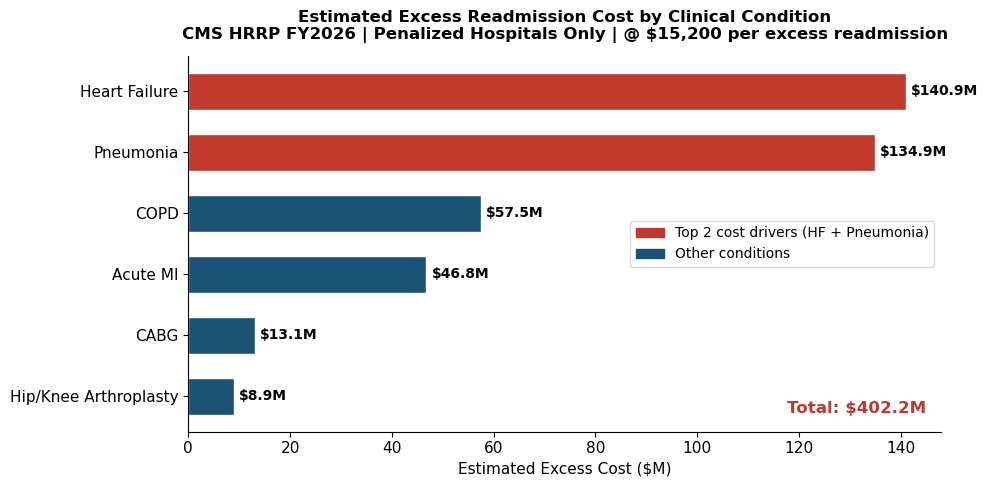

Saved: assets/chart4_excess_cost_by_condition.png


In [14]:
df_cost_sorted = df_cost.sort_values('excess_cost_m', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = [
    C['danger'] if c in ['Heart Failure','Pneumonia'] else C['primary']
    for c in df_cost_sorted['condition']
]

bars = ax.barh(
    df_cost_sorted['condition'],
    df_cost_sorted['excess_cost_m'],
    color=bar_colors, edgecolor='white', height=0.6
)

# Value labels
for bar, val in zip(bars, df_cost_sorted['excess_cost_m']):
    ax.text(
        val + 1, bar.get_y() + bar.get_height() / 2,
        f'${val:.1f}M', va='center', ha='left', fontsize=10, fontweight='bold'
    )

ax.set_title(
    'Estimated Excess Readmission Cost by Clinical Condition\n'
    'CMS HRRP FY2026 | Penalized Hospitals Only | @ $15,200 per excess readmission',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlabel('Estimated Excess Cost ($M)', fontsize=11)

total_cost = df_cost_sorted['excess_cost_m'].sum()
ax.text(0.98, 0.05, f'Total: ${total_cost:.1f}M',
        transform=ax.transAxes, fontsize=12,
        ha='right', color=C['danger'], fontweight='bold')

ax.legend(handles=[
    mpatches.Patch(color=C['danger'],  label='Top 2 cost drivers (HF + Pneumonia)'),
    mpatches.Patch(color=C['primary'], label='Other conditions')
], fontsize=10)

plt.tight_layout()
plt.savefig('assets/chart4_excess_cost_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: assets/chart4_excess_cost_by_condition.png')

---
## Chart 5: Penalty Rate by Hospital Ownership Type

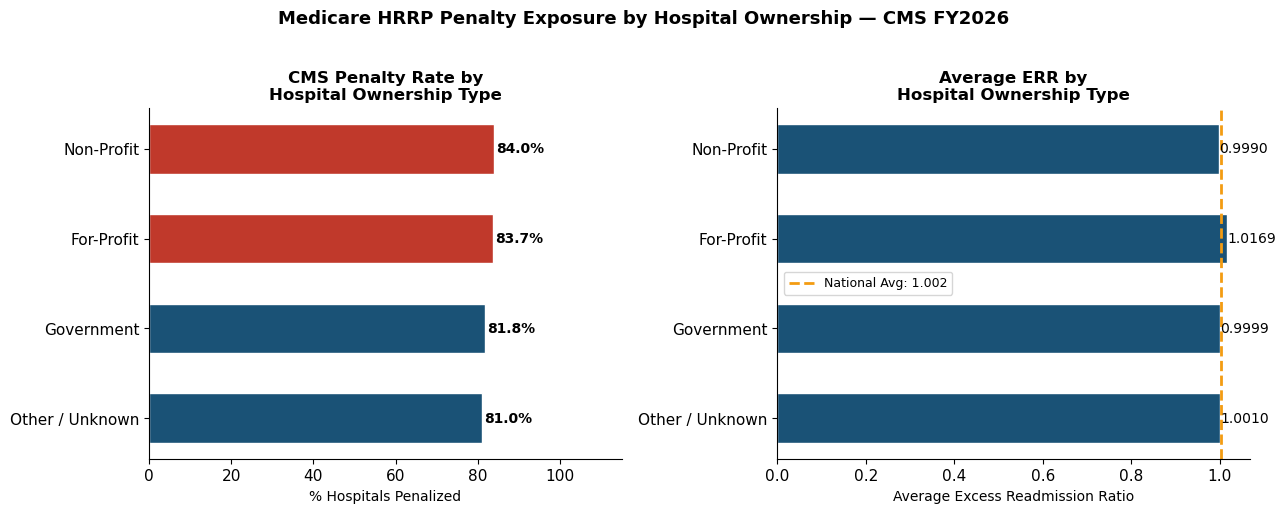

Saved: assets/chart5_penalty_by_ownership.png


In [33]:
ownership_stats = (
    df.groupby('ownership_group')
    .apply(lambda x: pd.Series({
        'hospital_count': x['facility_id'].nunique(),
        'penalized'     : x[x['penalty_flag']==True]['facility_id'].nunique(),
        'avg_err'       : x['excess_readmit_ratio'].mean()
    }))
    .reset_index()
)
ownership_stats['penalty_pct'] = (
    ownership_stats['penalized'] / ownership_stats['hospital_count'] * 100
).round(1)
ownership_stats = ownership_stats.sort_values('penalty_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: penalty rate
bar_colors = [
    C['danger'] if p > 83 else C['primary']
    for p in ownership_stats['penalty_pct']
]
bars = axes[0].barh(
    ownership_stats['ownership_group'],
    ownership_stats['penalty_pct'],
    color=bar_colors, edgecolor='white', height=0.55
)
for bar, val in zip(bars, ownership_stats['penalty_pct']):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[0].set_title('CMS Penalty Rate by\nHospital Ownership Type',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('% Hospitals Penalized', fontsize=10)
axes[0].set_xlim(0, 115)

# Right: avg ERR
axes[1].barh(
    ownership_stats['ownership_group'],
    ownership_stats['avg_err'],
    color=C['primary'], edgecolor='white', height=0.55
)
axes[1].axvline(x=NATIONAL_AVG_ERR, color=C['highlight'],
                linewidth=2, linestyle='--',
                label=f'National Avg: {NATIONAL_AVG_ERR:.3f}')
for bar, val in zip(axes[1].patches, ownership_stats['avg_err']):
    axes[1].text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)
axes[1].set_title('Average ERR by\nHospital Ownership Type',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Excess Readmission Ratio', fontsize=10)
axes[1].legend(fontsize=9)

plt.suptitle('Medicare HRRP Penalty Exposure by Hospital Ownership — CMS FY2026',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('assets/chart5_penalty_by_ownership.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: assets/chart5_penalty_by_ownership.png')

---
## Chart 6: Top 10 vs Bottom 10 States (Side-by-Side)
*The contrast chart — goes in LinkedIn post and README*

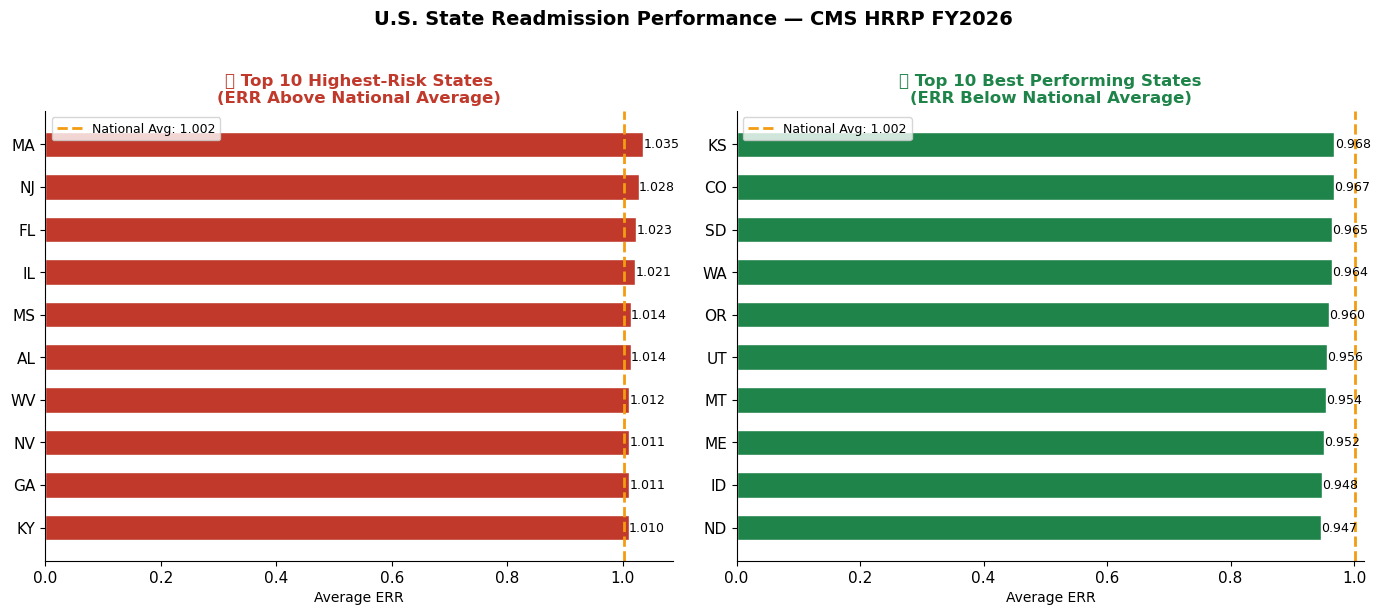

Saved: assets/chart6_top_bottom_states.png


In [20]:
top10    = df_state.nlargest(10,  'state_avg_err').sort_values('state_avg_err')
bottom10 = df_state.nsmallest(10, 'state_avg_err').sort_values('state_avg_err')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 worst
axes[0].barh(top10['state'], top10['state_avg_err'],
             color=C['danger'], edgecolor='white', height=0.6)
axes[0].axvline(x=NATIONAL_AVG_ERR, color=C['highlight'],
                linewidth=2, linestyle='--',
                label=f'National Avg: {NATIONAL_AVG_ERR:.3f}')
for bar, val in zip(axes[0].patches, top10['state_avg_err']):
    axes[0].text(val + 0.0003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
axes[0].set_title('🔴 Top 10 Highest-Risk States\n(ERR Above National Average)',
                  fontsize=12, fontweight='bold', color=C['danger'])
axes[0].set_xlabel('Average ERR', fontsize=10)
axes[0].legend(fontsize=9)

# Bottom 10 best
axes[1].barh(bottom10['state'], bottom10['state_avg_err'],
             color=C['safe'], edgecolor='white', height=0.6)
axes[1].axvline(x=NATIONAL_AVG_ERR, color=C['highlight'],
                linewidth=2, linestyle='--',
                label=f'National Avg: {NATIONAL_AVG_ERR:.3f}')
for bar, val in zip(axes[1].patches, bottom10['state_avg_err']):
    axes[1].text(val + 0.0003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
axes[1].set_title('🟢 Top 10 Best Performing States\n(ERR Below National Average)',
                  fontsize=12, fontweight='bold', color=C['safe'])
axes[1].set_xlabel('Average ERR', fontsize=10)
axes[1].legend(fontsize=9)

plt.suptitle('U.S. State Readmission Performance — CMS HRRP FY2026',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('assets/chart6_top_bottom_states.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: assets/chart6_top_bottom_states.png')

In [29]:
print('\n All 6 charts saved to assets/ folder:')
for f in sorted(os.listdir('assets')):
    if f.endswith('.png'):
        size_kb = os.path.getsize(f'assets/{f}') / 1024
        print(f'  {f:<45} {size_kb:.0f} KB')




 All 6 charts saved to assets/ folder:
  chart1_err_by_condition.png                   139 KB
  chart2_state_performance.png                  182 KB
  chart3_condition_bubble.png                   120 KB
  chart4_excess_cost_by_condition.png           84 KB
  chart5_penalty_by_ownership.png               86 KB
  chart6_top_bottom_states.png                  109 KB
